In [84]:
import pandas as pd
import geopandas as gpd
# import geodatasets as gd
import matplotlib.pyplot as matplt

import seaborn as sns

url = "https://raw.githubusercontent.com/miab199/gwc-water/refs/heads/main/Self%20Supplied%20Industrial%20Water%20Use%20in%20the%20Tennessee%20Hydrologic%20Region%202010.csv?scrlybrkr=496e2411"
df = pd.read_csv(url)
df.head()


,County,Source of supply,Principal aquifer,Groundwater withdrawal (Mgal/d),Major river basin,Surface water withdrawal (Mgal/d)
0,Anderson,Clinch River,--,--,Upper Tennessee,0.524
1,Bradley,Hiwassee River,--,--,Middle Tennessee-Hiwassee,3.81
2,Carter,Well #1 & #2,Cambrian-Ordovician carbonate,0.134,--,--
3,Cocke,Well fields,Cambrian-Ordovician carbonate,0.214,--,--
4,Coffee,Well,Mississippian carbonate,0.020,--,--


In [70]:
numRows = len(df)
print("rows: ", numRows)

numColumns = len(df.columns)
print("columns: ", numColumns)

rows:  85
columns:  6


How concentrated is industrial water control in the Tennessee hydrologic region, and which communities bear the greatest extraction burden?
Cardinal Directions
Rural/Suburban/Urban
Which industrial sectors create the highest water stress relative to their geographic footprint?
3. Which counties are most structurally dependent on self-supplied industrial water, and what does that imply for long-term sustainability?

In [71]:
# looking for data about nas and nans
df.isna()

#find nas (axis 1 = rows, 0 = columns)
print(df.isna().any(axis=1))
# print(df.isna().sum(axis = 0 ))

0     False
1     False
2     False
3     False
4     False
      ...  
80     True
81     True
82     True
83     True
84     True
Length: 85, dtype: bool


In [72]:
df_clean = df.dropna()
df_clean

,County,Source of supply,Principal aquifer,Groundwater withdrawal (Mgal/d),Major river basin,Surface water withdrawal (Mgal/d)
0,Anderson,Clinch River,--,--,Upper Tennessee,0.524
1,Bradley,Hiwassee River,--,--,Middle Tennessee-Hiwassee,3.81
2,Carter,Well #1 & #2,Cambrian-Ordovician carbonate,0.134,--,--
3,Cocke,Well fields,Cambrian-Ordovician carbonate,0.214,--,--
4,Coffee,Well,Mississippian carbonate,0.020,--,--
...,...,...,...,...,...,...
58,Sullivan,South Fork of Holston River,--,--,French Broad-Holston,17.3
59,Sullivan,Holston River area B,--,--,French Broad-Holston,18.9
60,Sullivan,South Fork Holston River,--,--,French Broad-Holston,58.5
61,Sullivan,South Fork Holston River,--,--,French Broad-Holston,104


clean up NAs or NaNs (detect NAs and decide on removal)
how much water from rivers/wells?
how many unique aquifers?

In [73]:
df_surface = df_clean[df_clean["Groundwater withdrawal (Mgal/d)"] == "--"]
df_surface
num_surface = pd.to_numeric(df_surface["Surface water withdrawal (Mgal/d)"]).sum()
print("total surface water: ", num_surface)


total surface water:  703.7


In [74]:
df_ground = df_clean[df_clean["Surface water withdrawal (Mgal/d)"] == "--"]
df_ground
num_ground = pd.to_numeric(df_ground["Groundwater withdrawal (Mgal/d)"]).sum()
print("total ground water: ", num_ground)

total ground water:  6.4292


we found that there was a lot more surface water used, compared to ground water. There was 703.7 Mgal/d of surface water in total, and 6.4292 Mgal/d of ground water in total

In [75]:
num_rows_surface = len(df_surface)
avg_surface = num_surface / num_rows_surface
print("Average surface withdrawl: ", avg_surface)

Average surface withdrawl:  21.990625


In [76]:
num_rows_ground = len(df_ground)
avg_ground = num_ground / num_rows_ground
print("Average ground withdrawl: ", avg_ground)

Average ground withdrawl:  0.20739354838709675


They got more water from each surface withdrawl on average than each ground withdrawl on average. They got an average of 21.9906 Mgal/d of surface water and an average of 0.2074 Mgal/d of ground water.

In [77]:
print("number of unique surface water supply sources: ", df_surface['Source of supply'].nunique())

number of unique surface water supply sources:  20


In [78]:
print("number of unique ground water supply sources: ", df_ground['Source of supply'].nunique())

number of unique ground water supply sources:  18


there are 20 unique surface water sources and 18 unique ground water sources
BUT not necesarilly useful/correct info because some differences seem to by typos/stylistic choices

NameError: name 'plt' is not defined

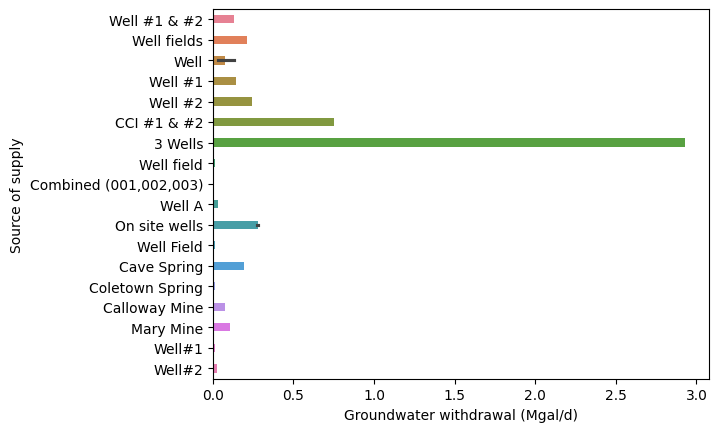

In [79]:
GW = pd.to_numeric(df_ground["Groundwater withdrawal (Mgal/d)"])
sns.barplot(df_ground, y = "Source of supply", x = GW, hue = "Source of supply", gap = 0.5, native_scale = False, orient = "y")
plt.set_title("Groundwater Withdrawl vs Supply Location")
plt.show()

next:

add for suface water - done
figure out what it means

In [ ]:
SW = pd.to_numeric(df_surface["Surface water withdrawal (Mgal/d)"])
plt_surface = sns.barplot(df_surface, y = "Source of supply", x = SW, hue = "Source of supply", gap = 0.5, native_scale = False, orient = "y")
plt_surface.set_title("Surface Water Withdrawl vs Supply Location")
plt_surface

In [ ]:
# county_df_ground = df_ground[['County'], df_ground['Groundwater withdrawal (Mgal/d)']].copy()

# county_df_ground

In [ ]:
df_ground

In [ ]:
data = {
    'County': ['Anderson', 'Bradley', 'Carter', 'Cocke', 'Coffee', 'Coffee', 'Franklin', 'Greene', 'Hamilton'],
    'Groundwater_withdrawal': [0.524, 0.0, 0.134, 0.214, 0.020, 0.023, 0.023, 0.0, 0.0002]
}
df = pd.DataFrame(data)

GroundW = pd.to_numeric(df_ground["Groundwater withdrawal (Mgal/d)"])


# # 2. Aggregate data by County (Summing multiple entries for one county, like Coffee)
df_grouped = df_ground.groupby('County')[GroundW].sum().reset_index()

# # # 3. Load Tennessee County Boundaries (GeoJSON)
# # # You can find TN county GeoJSONs from sources like the US Census or TN GIS portals
# tn_map_url = "https://raw.githubusercontent.com/miab199/gwc-water/refs/heads/main/TN_counties_2016.csv"
# tn_gdf = gpd.read_file(tn_map_url)

# # # 4. Merge the geographic data with your water data
# # # Note: Ensure county names match (e.g., "Hamilton" in both datasets)
# merged = tn_gdf.merge(df_grouped, left_on='NAME', right_on='County', how='left')

# # # 5. Plot the Choropleth Map
# fig, ax = matplt.subplots(1, 1, figsize=(12, 8))
# merged.plot(column='Groundwater withdrawal (Mgal/d)',
#             ax=ax,
#             legend=True,
#             cmap='Blues')
#             # missing_kwds={'color': 'lightgrey'}, # Counties with no data
#             # legend_kwds={'label': "Groundwater Withdrawal (Mgal/d)"})

# ax.set_title("Self-Supplied Industrial Groundwater Use by Tennessee County", fontsize=15)
# ax.axis('off')
# # matplotlib.pyplot.show()

This diagram/picture proves:
Water usage is not evenly distributed across counties in Tennessee: some areas use way more water than others.

In [83]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import requests
from io import StringIO

# --- Data (shortened for clarity) ---
data = """County,Surface
Anderson,0.524
Bradley,3.81
Coffee,0.919
Franklin,34.323
Greene,1.47
Hamilton,4.74
Hardin,25.0
Humphreys,66.0
Knox,1.95
McMinn,35.2
Sullivan,279
"""

df = pd.read_csv(StringIO(data))

# --- County GeoJSON ---
geojson = requests.get(
    "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
).json()

tn = [f for f in geojson["features"] if f["id"].startswith("47")]
tn_geojson = {"type": "FeatureCollection", "features": tn}

# Map names → FIPS
fips_map = {f["properties"]["NAME"]: f["id"] for f in tn}
df["fips"] = df["County"].map(fips_map)
df = df.dropna()

# --- Base map ---
fig = px.choropleth(
    df,
    geojson=tn_geojson,
    locations="fips",
    color="Surface",
    featureidkey="id",
    color_continuous_scale="Blues"
)

# County borders
fig.update_traces(marker_line_color="black", marker_line_width=1)

# --- SIMPLE STATE OUTLINE ---
state_geo = requests.get(
    "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
).json()

tn_outline = [f for f in state_geo["features"] if f["properties"]["name"] == "Tennessee"]

fig.add_trace(go.Choropleth(
    geojson={"type": "FeatureCollection", "features": tn_outline},
    locations=["Tennessee"],
    z=[1],
    featureidkey="properties.name",
    colorscale=[[0, "rgba(0,0,0,0)"], [1, "rgba(0,0,0,0)"]],
    marker_line_color="black",
    marker_line_width=3,   # 👈 bold outer border
    showscale=False
))

# Zoom
fig.update_geos(fitbounds="locations", visible=False)

fig.update_layout(title="Tennessee Water Trends")

fig.show()

Map of TN showing the Most Common Water Source by County in Tennessee

In [86]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import requests
from io import StringIO

# --- Original data ---
data = """County,Source of supply,Principal aquifer,Groundwater withdrawal (Mgal/d),Major river basin,Surface water withdrawal (Mgal/d)
Anderson,Clinch River,--,--,Upper Tennessee,0.524
Bradley,Hiwassee River,--,--,Middle Tennessee-Hiwassee,3.81
Carter,Well #1 & #2,Cambrian-Ordovician carbonate,0.134,--,--
Cocke,Well fields,Cambrian-Ordovician carbonate,0.214,--,--
Coffee,Well,Mississippian carbonate,0.020,--,--
Coffee,Well,Mississippian carbonate,0.023,--,--
Coffee,Well,Mississippian carbonate,0.041,--,--
Coffee,Well,Mississippian carbonate,0.044,--,--
Coffee,Well,Mississippian carbonate,0.056,--,--
Coffee,Well,Mississippian carbonate,0.091,--,--
Coffee,Well,Mississippian carbonate,0.138,--,--
Coffee,Cascade Creek,--,--,Lower Tennessee,0.141
Coffee,Well,Mississippian carbonate,0.365,--,--
Decatur,Tennessee River,--,--,Lower Tennessee,0.005
Franklin,Well,Mississippian carbonate,0.023,--,--
Franklin,Primary Pumping Station,--,--,Middle Tennessee-Elk,34.3
Greene,Sinking Creek,--,--,French Broad-Holston,1.47
Hamilton,Tennessee River,--,--,Middle Tennessee-Hiwassee,4.74
Hardin,Tennessee River,--,--,Middle Tennessee-Elk,25.0
Humphreys,Tennessee River,--,--,Lower Tennessee,66.0
Knox,Holston River/Quarry,--,--,French Broad-Holston,1.95
McMinn,Hiwassee River (RW2/1),--,--,Middle Tennessee-Hiwassee,35.2
Sullivan,South Fork Holston River,--,--,French Broad-Holston,279
"""

df = pd.read_csv(StringIO(data))

# --- Find MOST COMMON source per county ---
most_common_source = (
    df.groupby(["County", "Source of supply"])
      .size()
      .reset_index(name="count")
      .sort_values(["County", "count"], ascending=[True, False])
      .drop_duplicates("County")
)

# --- Load Tennessee counties ---
geojson = requests.get(
    "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
).json()

tn = [f for f in geojson["features"] if f["id"].startswith("47")]
tn_geojson = {"type": "FeatureCollection", "features": tn}

# Map county → FIPS
fips_map = {f["properties"]["NAME"]: f["id"] for f in tn}
most_common_source["fips"] = most_common_source["County"].map(fips_map)
most_common_source = most_common_source.dropna()

# --- Create map ---
fig = px.choropleth(
    most_common_source,
    geojson=tn_geojson,
    locations="fips",
    color="Source of supply",   # 👈 categorical coloring
    featureidkey="id"
)

# County borders
fig.update_traces(marker_line_color="black", marker_line_width=1)

# --- Add Tennessee outline ---
state_geo = requests.get(
    "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
).json()

tn_outline = [f for f in state_geo["features"] if f["properties"]["name"] == "Tennessee"]

fig.add_trace(go.Choropleth(
    geojson={"type": "FeatureCollection", "features": tn_outline},
    locations=["Tennessee"],
    z=[1],
    featureidkey="properties.name",
    colorscale=[[0, "rgba(0,0,0,0)"], [1, "rgba(0,0,0,0)"]],
    marker_line_color="black",
    marker_line_width=3,
    showscale=False
))

# Zoom + layout
fig.update_geos(fitbounds="locations", visible=False)

fig.update_layout(
    title="Most Common Water Source by County in Tennessee"
)

fig.show()

Map of TN based on the Major RIver Basin for the Water Data Set

In [87]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import requests
from io import StringIO

# --- Original data ---
data = """County,Major river basin
Anderson,Upper Tennessee
Bradley,Middle Tennessee-Hiwassee
Carter,--
Cocke,--
Coffee,Lower Tennessee
Decatur,Lower Tennessee
Franklin,Middle Tennessee-Elk
Greene,French Broad-Holston
Hamilton,Middle Tennessee-Hiwassee
Hardin,Middle Tennessee-Elk
Humphreys,Lower Tennessee
Knox,French Broad-Holston
McMinn,Middle Tennessee-Hiwassee
Sullivan,French Broad-Holston
"""

df = pd.read_csv(StringIO(data))

# --- Fill missing basins with "Unknown" ---
df["Major river basin"] = df["Major river basin"].replace("--", "Unknown")

# --- If multiple rows per county, pick the most common ---
most_common_basin = (
    df.groupby(["County", "Major river basin"])
      .size()
      .reset_index(name="count")
      .sort_values(["County", "count"], ascending=[True, False])
      .drop_duplicates("County")
)

# --- Load Tennessee counties GeoJSON ---
geojson = requests.get(
    "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
).json()

tn = [f for f in geojson["features"] if f["id"].startswith("47")]
tn_geojson = {"type": "FeatureCollection", "features": tn}

# Map county → FIPS
fips_map = {f["properties"]["NAME"]: f["id"] for f in tn}
most_common_basin["fips"] = most_common_basin["County"].map(fips_map)
most_common_basin = most_common_basin.dropna()

# --- Create map ---
fig = px.choropleth(
    most_common_basin,
    geojson=tn_geojson,
    locations="fips",
    color="Major river basin",   # categorical coloring
    featureidkey="id"
)

# County borders
fig.update_traces(marker_line_color="black", marker_line_width=1)

# --- Add Tennessee outline ---
state_geo = requests.get(
    "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
).json()

tn_outline = [f for f in state_geo["features"] if f["properties"]["name"] == "Tennessee"]

fig.add_trace(go.Choropleth(
    geojson={"type": "FeatureCollection", "features": tn_outline},
    locations=["Tennessee"],
    z=[1],
    featureidkey="properties.name",
    colorscale=[[0, "rgba(0,0,0,0)"], [1, "rgba(0,0,0,0)"]],
    marker_line_color="black",
    marker_line_width=3,   # thick outer border
    showscale=False
))

# Zoom + layout
fig.update_geos(fitbounds="locations", visible=False)

fig.update_layout(
    title="Major River Basin by County in Tennessee"
)

fig.show()